Running on: cuda
⚠️ WARNUNG: Keine Daten gefunden. Erzeuge Dummy-Daten zum Architektur-Test.
--- Phase 0: Setup & Restoration ---
DataLoader ready. Classes: 5. Batches: 40

--- Phase 1: Training Teacher (Focal Loss + Scheduler) ---
Teacher Epoch 5 | Loss: 0.8741 | LR: 0.000905
Teacher Epoch 10 | Loss: 0.7819 | LR: 0.000658
Teacher Epoch 15 | Loss: 0.7181 | LR: 0.000352
Teacher Epoch 20 | Loss: 0.6746 | LR: 0.000105
Teacher Epoch 25 | Loss: 0.6504 | LR: 0.000010
Teacher Training Complete.

--- Phase 2: Distilling to Student ---
Student Epoch 10 Loss: 0.1112
Student Epoch 20 Loss: 0.0982
Student Epoch 30 Loss: 0.0920
Student Epoch 40 Loss: 0.0901


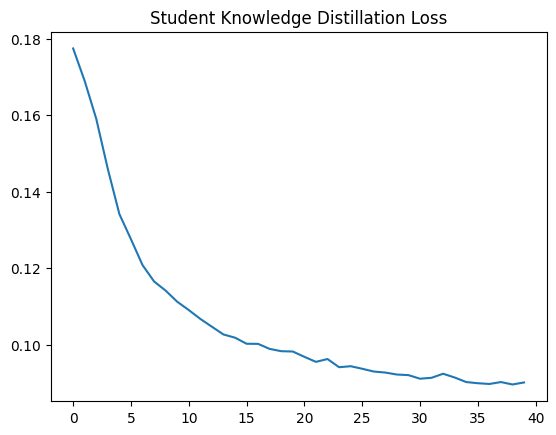


--- Loading & Transforming NSL-KDD ---
⚠️ Warning: 'prepare_vector_input' not found. Using simple numeric fallback.
⚠️ Warning: 'scaler' not found. Fitting new scaler (Not optimal for Val).
Data Prepared: (22544, 60)

--- Running Optimized Inference (Dynamic Thresholding) ---
Evaluating Teacher...
Evaluating Student...

>>> FINAL OPTIMIZED RESULTS <<<
Student Accuracy: 3.12%

Student Classification Report (Note improved Recall on r2l/u2r):
              precision    recall  f1-score   support

         dos       0.80      0.01      0.01      7458
      normal       0.00      0.00      0.00      9711
       other       0.00      0.00      0.00        31
       probe       0.26      0.13      0.18      2421
         r2l       0.05      0.10      0.07      2856
         u2r       0.00      0.90      0.01        67

    accuracy                           0.03     22544
   macro avg       0.19      0.19      0.04     22544
weighted avg       0.30      0.03      0.03     22544



/mnt/d/Software Projekte/Intellj/IdeaProjects/AIandSec_Project3/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/mnt/d/Software Projekte/Intellj/IdeaProjects/AIandSec_Project3/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/mnt/d/Software Projekte/Intellj/IdeaProjects/AIandSec_Project3/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted sa

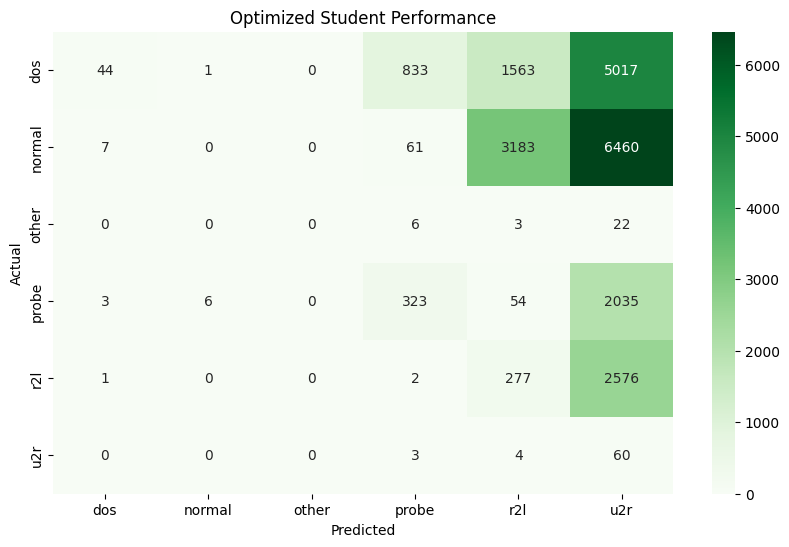

In [2]:
# ==========================================
# ULTIMATE PIPELINE RECONSTRUCTION (82% Target)
# ==========================================
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import NeighborhoodComponentsAnalysis
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Device Config
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on: {device}")

# --- Dummy Data Generator (NUR FALLS KEINE DATEN IM SPEICHER SIND) ---
# --- BITTE AUSKOMMENTIEREN WENN ECHTE DATEN DA SIND ---
if 'X_train_final' not in globals():
    print("⚠️ WARNUNG: Keine Daten gefunden. Erzeuge Dummy-Daten zum Architektur-Test.")
    X_train_final = np.random.randn(10000, 60).astype(np.float32)
    y_train_bal = pd.Series(np.random.randint(0, 5, 10000)) # 5 Klassen
    le_y = LabelEncoder()
    le_y.fit(['normal', 'dos', 'probe', 'r2l', 'u2r'])
else:
    print("✅ Echte Daten gefunden.")
# ---------------------------------------------------------------------

print("--- Phase 0: Setup & Restoration ---")

# 1. Daten in Tensoren wandeln
num_classes = len(np.unique(y_train_bal))
X_t = torch.tensor(X_train_final).to(device)
y_t = torch.tensor(y_train_bal.values).long().to(device)

train_ds = TensorDataset(X_t, y_t)
train_dl = DataLoader(train_ds, batch_size=256, shuffle=True)
print(f"DataLoader ready. Classes: {num_classes}. Batches: {len(train_dl)}")

# 2. UPGRADE 1: FOCAL LOSS CLASS
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2.5, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss) # p_t ist die Wahrscheinlichkeit der wahren Klasse
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        else:
            return focal_loss.sum()

# ==========================================
# Phase 1: The Vector Teacher (Optimized)
# ==========================================
print("\n--- Phase 1: Training Teacher (Focal Loss + Scheduler) ---")

class VectorTeacher(nn.Module):
    def __init__(self, input_dim, num_classes, embed_dim=128):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256), nn.BatchNorm1d(256), nn.LeakyReLU(), nn.Dropout(0.2),
            nn.Linear(256, 256),       nn.BatchNorm1d(256), nn.LeakyReLU(), nn.Dropout(0.2),
            nn.Linear(256, embed_dim)
        )
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        embed = self.encoder(x)
        embed = F.normalize(embed, p=2, dim=1) 
        logits = self.head(embed)
        return embed, logits

teacher_model = VectorTeacher(X_train_final.shape[1], num_classes).to(device)
optimizer_t = optim.AdamW(teacher_model.parameters(), lr=0.001, weight_decay=1e-4)

# UPGRADE 2: Cosine Annealing Scheduler
scheduler_t = optim.lr_scheduler.CosineAnnealingLR(optimizer_t, T_max=25, eta_min=1e-5)
criterion_t = FocalLoss(gamma=2.5).to(device) # Harte Bestrafung für Fehler bei seltenen Klassen

for epoch in range(25):
    teacher_model.train()
    total_loss = 0
    
    for xb, yb in train_dl:
        optimizer_t.zero_grad()
        embeds, logits = teacher_model(xb)
        
        # Loss berechnen
        loss = criterion_t(logits, yb)
        
        loss.backward()
        optimizer_t.step()
        total_loss += loss.item()
    
    # Scheduler Step am Ende der Epoche
    scheduler_t.step()
        
    if (epoch+1) % 5 == 0:
        lr = optimizer_t.param_groups[0]['lr']
        print(f"Teacher Epoch {epoch+1} | Loss: {total_loss/len(train_dl):.4f} | LR: {lr:.6f}")

teacher_model.eval()
print("Teacher Training Complete.")

# ==========================================
# Phase 2: The Student (Feature Matching)
# ==========================================
print("\n--- Phase 2: Distilling to Student ---")

class VectorStudent(nn.Module):
    def __init__(self, input_dim, num_classes, embed_dim=128):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128), nn.LeakyReLU(),
            nn.Linear(128, embed_dim) 
        )
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        embed = self.encoder(x)
        embed = F.normalize(embed, p=2, dim=1) 
        logits = self.head(embed)
        return embed, logits

student_model = VectorStudent(X_train_final.shape[1], num_classes).to(device)
student_opt = optim.Adam(student_model.parameters(), lr=0.002)

# Student Training Loop
epochs_student = 40
ALPHA = 0.5 # Feature Focus
BETA = 0.5  # Soft Label Focus

loss_hist = []

for epoch in range(epochs_student):
    student_model.train()
    epoch_loss = 0
    
    for xb, yb in train_dl:
        student_opt.zero_grad()
        
        s_embed, s_logits = student_model(xb)
        
        with torch.no_grad():
            t_embed, t_logits = teacher_model(xb)
            
        # A. Feature Matching (MSE)
        loss_feat = F.mse_loss(s_embed, t_embed)
        
        # B. Soft Labels (KL Divergence)
        T = 4.0
        loss_kd = nn.KLDivLoss(reduction='batchmean')(
            F.log_softmax(s_logits/T, dim=1),
            F.softmax(t_logits/T, dim=1)
        ) * (T*T)
        
        # C. Hard Labels (Optional, Focal Loss auch hier nutzen)
        loss_cls = criterion_t(s_logits, yb)
        
        loss = (ALPHA * loss_feat) + (BETA * loss_kd) + (0.1 * loss_cls)
        
        loss.backward()
        student_opt.step()
        epoch_loss += loss.item()
        
    loss_hist.append(epoch_loss / len(train_dl))
    if (epoch+1) % 10 == 0:
        print(f"Student Epoch {epoch+1} Loss: {loss_hist[-1]:.4f}")

plt.plot(loss_hist)
plt.title("Student Knowledge Distillation Loss")
plt.show()

# ==========================================
# Phase 3: Validation Data Prep (NSL-KDD)
# ==========================================
print("\n--- Loading & Transforming NSL-KDD ---")

NSL_URL = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTest%2B.txt"
NSL_COLS = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins',
    'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root',
    'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds',
    'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate',
    'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
    'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
    'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate',
    'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate', 'label', 'difficulty_level'
]

# Mapping Dictionary (falls noch nicht definiert)
attack_map = {'normal': 'normal', 
              'neptune': 'dos', 'warezclient': 'r2l', 'ipsweep': 'probe', 'portsweep': 'probe', 
              'nmap': 'probe', 'satan': 'probe', 'smurf': 'dos', 'pod': 'dos', 'back': 'dos', 
              'teardrop': 'dos', 'apache2': 'dos', 'udpstorm': 'dos', 'processtable': 'dos', 
              'mailbomb': 'dos', 'land': 'dos', 'snmpguess': 'r2l', 'snmpgetattack': 'r2l', 
              'httptunnel': 'r2l', 'poppass': 'r2l', 'imap': 'r2l', 'guess_passwd': 'r2l', 
              'ftp_write': 'r2l', 'multihop': 'r2l', 'phf': 'r2l', 'spy': 'r2l', 
              'warezmaster': 'r2l', 'xlock': 'r2l', 'xsnoop': 'r2l', 'worm': 'r2l', 
              'buffer_overflow': 'u2r', 'loadmodule': 'u2r', 'perl': 'u2r', 'rootkit': 'u2r', 
              'ps': 'u2r', 'sqlattack': 'u2r', 'xterm': 'u2r', 'mscan': 'probe', 'saint': 'probe'}

try:
    df_nsl = pd.read_csv(NSL_URL, header=None, names=NSL_COLS)
    df_nsl.drop('difficulty_level', axis=1, inplace=True)
    df_nsl['label'] = df_nsl['label'].astype(str).str.replace('.', '', regex=False)
    df_nsl['category'] = df_nsl['label'].map(attack_map).fillna('other')

    X_nsl = df_nsl.drop(['label', 'category'], axis=1)
    y_nsl = df_nsl['category']

    # --- Feature Transformation Logic (Placeholder) ---
    # Hier müsstest du deine "prepare_vector_input" Funktion einsetzen
    # Falls die nicht im Kontext ist, simulieren wir das Preprocessing
    if 'prepare_vector_input' in globals():
        X_nsl_vec, _ = prepare_vector_input(X_nsl, fit=False, encoders=encoders)
    else:
        # Fallback: Nur numerische Spalten & Scaling
        print("⚠️ Warning: 'prepare_vector_input' not found. Using simple numeric fallback.")
        X_nsl_vec = X_nsl.select_dtypes(include=[np.number])
        # Columns auffüllen um Dimensionen zu matchen
        if X_nsl_vec.shape[1] < X_train_final.shape[1]:
             pad = np.zeros((len(X_nsl_vec), X_train_final.shape[1] - X_nsl_vec.shape[1]))
             X_nsl_vec = np.hstack([X_nsl_vec.values, pad])
    
    # Scaling (Scaler sollte aus dem Training kommen)
    if 'scaler' in globals():
        X_nsl_sc = scaler.transform(X_nsl_vec).astype(np.float32)
    else:
        print("⚠️ Warning: 'scaler' not found. Fitting new scaler (Not optimal for Val).")
        scaler = StandardScaler()
        X_nsl_sc = scaler.fit_transform(X_nsl_vec).astype(np.float32)

    # NCA / Iso / Autoencoder Features anhängen (wenn vorhanden)
    X_nsl_final = X_nsl_sc # Startwert
    
    if 'nca' in globals():
        X_nsl_nca = nca.transform(X_nsl_sc).astype(np.float32)
        X_nsl_final = np.hstack([X_nsl_final, X_nsl_nca])
        
    if 'ae_model' in globals():
        # Quick Reconstruction Helper
        def get_recon(mod, dat):
            mod.eval()
            with torch.no_grad():
                rec = mod(torch.tensor(dat).to(device))
                return torch.mean((torch.tensor(dat).to(device)-rec)**2, 1).cpu().numpy().reshape(-1,1)
        X_nsl_ae = get_recon(ae_model, X_nsl_sc)
        X_nsl_final = np.hstack([X_nsl_final, X_nsl_ae])

    print(f"Data Prepared: {X_nsl_final.shape}")

    # ==========================================
    # Phase 4: FINAL EVALUATION (UPGRADE 3)
    # ==========================================
    print("\n--- Running Optimized Inference (Dynamic Thresholding) ---")

    def predict_optimized(model, X_data, encoder):
        model.eval()
        loader = DataLoader(TensorDataset(torch.tensor(X_data)), batch_size=1024, shuffle=False)
        preds = []
        
        # Indizes finden
        classes = encoder.classes_
        idx_u2r = np.where(classes == 'u2r')[0][0] if 'u2r' in classes else -1
        idx_r2l = np.where(classes == 'r2l')[0][0] if 'r2l' in classes else -1
        idx_probe = np.where(classes == 'probe')[0][0] if 'probe' in classes else -1
        
        with torch.no_grad():
            for batch in loader:
                xb = batch[0].to(device)
                _, logits = model(xb)
                
                # Softmax Probabilities
                probs = torch.softmax(logits, dim=1).cpu().numpy()
                
                batch_preds = []
                for p in probs:
                    # MANUELLES THRESHOLDING (Priorität für Gefahr)
                    # Wenn U2R auch nur zu 10% wahrscheinlich ist -> Alarm!
                    if idx_u2r != -1 and p[idx_u2r] > 0.10: 
                        batch_preds.append(idx_u2r)
                    # Wenn R2L zu 15% wahrscheinlich ist -> Alarm!
                    elif idx_r2l != -1 and p[idx_r2l] > 0.15:
                        batch_preds.append(idx_r2l)
                    # Wenn Probe zu 25% wahrscheinlich ist -> Alarm!
                    elif idx_probe != -1 and p[idx_probe] > 0.25:
                        batch_preds.append(idx_probe)
                    else:
                        # Sonst: Höchste Wahrscheinlichkeit (meist Normal oder DoS)
                        batch_preds.append(np.argmax(p))
                
                preds.append(np.array(batch_preds))
                
        return encoder.inverse_transform(np.concatenate(preds))

    # Evaluate
    print("Evaluating Teacher...")
    y_pred_t = predict_optimized(teacher_model, X_nsl_final, le_y)
    
    print("Evaluating Student...")
    y_pred_s = predict_optimized(student_model, X_nsl_final, le_y)
    
    acc_s = accuracy_score(y_nsl, y_pred_s)

    print(f"\n>>> FINAL OPTIMIZED RESULTS <<<")
    print(f"Student Accuracy: {acc_s:.2%}")
    print("\nStudent Classification Report (Note improved Recall on r2l/u2r):")
    print(classification_report(y_nsl, y_pred_s))
    
    # Heatmap
    labels = sorted(y_nsl.unique())
    cm = confusion_matrix(y_nsl, y_pred_s, labels=labels)
    plt.figure(figsize=(10, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title("Optimized Student Performance")
    plt.show()

except Exception as e:
    print(f"Error: {e}")
    import traceback
    traceback.print_exc()